# Game Tree Search

##Minimax
Minimax algorithm with **perfect decisions**:
- **No time limit** is imposed.
- The **complete search tree is generated**

但是实际上perfect decision很少见，更多的是imperfect decision:
- **Partial tree search**: Terminal test is replaced by a cutoff test.
- **Evaluation function**: Utility function is replaced by a heuristic evaluation function

###Evaluation Functions
三个Requirements:
1. **Computation** of evaluation function values is **efficient**.
2. Evaluation function **agrees with utility function on terminal states**.
3. Evaluation function accurately **reflects the chances of winning**.

####Example
Evalutaion function $e(p)$ satisfy:
1. If $p$ is not a winning position for either player, then: $$e(p) =  \text{num of complete rows, columns, or diagonals that are still open for MAX}- \text{num of complete rows, columns, or diagonals that are still open for MIN}$$
2. If $p$ is a win for MAX, then $e(p) = ∞$; if $p$ is a win for MIN, then $e(p) = −∞$.

##Quiescent Search
Quienscent Search也是一种Partial Tree Search

**Quiescent positions** are positions that are **not likely to have large variations in evaluation in the near future**.

Quiescent search:
 **Expansion of nonquiescent positions until quiescent positions are reached**. Check more details here if you are interested:
 https://www.chessprogramming.org/Quiescence_Search

##Alpha-Beta Pruning
算法：
1. Expand the node depth-first until a node that satisfies the cutoff test is reached. During expansion, pass current values of $α$ and $β$ of parent down to child nodes.
2. Evaluate the cutoff node.
3. Update the values of all the nodes that have so far been expanded according to Minimax algorithm.
4. Update the $(α,β)$ values of all the nodes that have so far been expanded according to:
 - **For MAX node, $α$ ← max($α$,current node value)**.
 - **For MIN node, $β$ ← min($β$,current node value)**.
5. **Prune all children of any node whose $α ≥ β$**
6. Backtrack to a node that has not been pruned, and go back to step 1. If there is no such node to backtrack to, then return with the value assigned to the root node.

```python
function MAX-VALUE(state,game, α, β)returns the minimax value of state
  inputs: state, current state in game
      game, game description
      α, the best score for MAX along the path to state
      β, the best score for MIN along the path to state
  if CUTOFF-TEST(state) then return EVAL(state)
  for each s in SUCCESSORS(state) do
    α = MAX(α, MIN-VALUE(s, game, α, β))
    if β ≤ α then return α
  end
  return β
```
```python

function MIN-VALUE(state,game, α, β) returns the minimax value of state
  if CUTOFF-TEST(state) then return EVAL(state)
  for each s in SUCCESSORS(state) do
    β = MIN(β ,MAX-VALUE(s,game, α, β))
    if β ≤ α then return
  end
  return
```

###Example

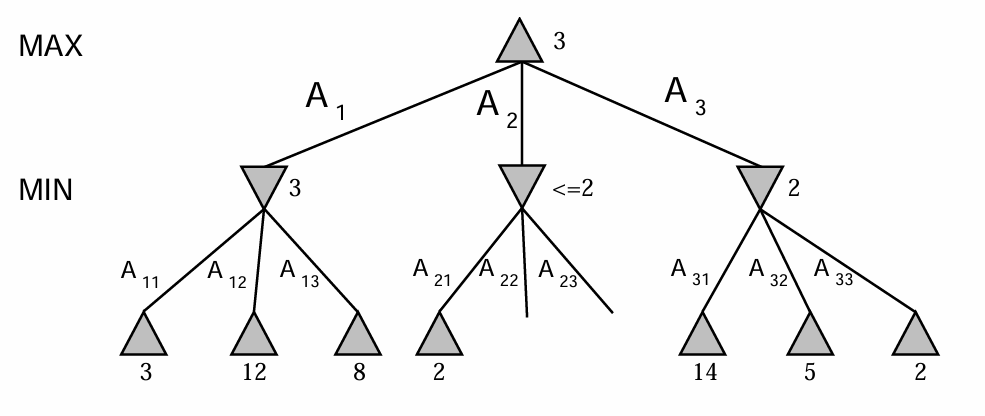

1. 在最左侧的min node会返回3。此时，我们在第一层的max node会update $\alpha$ value. $(\alpha, \beta) = (3, -\infty)$
2. 前往$A_{2}$, 由于$A_{21}$会返回2，则$(\alpha, \beta) = (3, 2)$, thus, $\alpha \ge \beta$, we conduct the pruning
3. 前往$A_{3}$, $A_{31}$会返回14，则$(\alpha, \beta) = (3, 14)$, 此时，$\alpha \le \beta$, continue
4. 前往$A_{3}$, $A_{32}$会返回14，则$(\alpha, \beta) = (3, 5)$, 此时，$\alpha \le \beta$, continue

##Analyses of Alpha-Beta Pruning Search Algorithm
The effectiveness of alpha-beta pruning search depends on the ordering in which successors are generated.

Assuming optimal ordering, alpha-beta pruning can reduce the branching factor from $b$ to $\sqrt{b}$ (Knuth and Moore 1975). The result also assumes that all nodes have the same branching factor, that all paths reach the same fixed depth limit, and that the leaf (cutoff node) evaluations are randomly distributed.

All the game-playing algorithms **assume** that the **opponent plays optimally**.

##Monte-Carlo Search
Monte-Carlo Search (Monte-Carlo Tree Search) is a heuristic search
algorithm, most employed to solve the game tree.
1. Expand the current node.
2. **For each child, play a large number of random games to the end and compute the average payoffs (values)**.
3. **Play the child move that has the largest average value**.